In [16]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib widget

In [17]:
import numba as nb

@nb.njit
def decode_spi(times: np.ndarray, cs: np.ndarray, clk: np.ndarray, mosi: np.ndarray, miso: np.ndarray, mode: int = 0, width: int = 8, cs_pol_high: bool = False):
    # Pre-allocate arrays (worst case: every width samples could be a byte)
    max_bytes = len(clk) // width + 1
    data_times = np.empty(max_bytes, dtype=np.float64)
    data_mosi = np.empty(max_bytes, dtype=np.int64)
    data_miso = np.empty(max_bytes, dtype=np.int64)
    
    current_byte_mosi = 0
    current_byte_miso = 0
    bit_count = 0
    cs_active = 1 if cs_pol_high else 0
    byte_count = 0
    
    sample_on_rising = mode == 0 or mode == 2

    for i in range(len(clk) - 1):
        if cs[i] == cs_active:
            clk_rising = clk[i] == 0 and clk[i + 1] == 1
            clk_falling = clk[i] == 1 and clk[i + 1] == 0

            if (sample_on_rising and clk_rising) or (not sample_on_rising and clk_falling):
                current_byte_mosi = (current_byte_mosi << 1) | mosi[i]
                current_byte_miso = (current_byte_miso << 1) | miso[i]
                bit_count += 1

                if bit_count == width:
                    data_times[byte_count] = times[i + 1]
                    data_mosi[byte_count] = current_byte_mosi
                    data_miso[byte_count] = current_byte_miso
                    byte_count += 1
                    current_byte_mosi = 0
                    current_byte_miso = 0
                    bit_count = 0

    return data_times[:byte_count], data_mosi[:byte_count], data_miso[:byte_count]

spi_data = tuple[tuple[np.ndarray, np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]

def parse_decode_signals(data: np.ndarray, f_acq: float, channels: dict[str, int]) -> spi_data:
    data = np.unpackbits(data, bitorder='little').reshape(-1, 8)
    time = np.arange(len(data)) / f_acq
    
    edge_idxs = np.diff(data, axis=0).nonzero()[0] + 1
    data_edges = data[edge_idxs]
    time_edges = time[edge_idxs]

    cs = data_edges[:, channels['nCS']]
    clk = data_edges[:, channels['CLK']]
    mosi = data_edges[:, channels['MOSI']]
    miso = data_edges[:, channels['MISO']]

    spi_times, spi_mosi, spi_miso = decode_spi(time_edges, cs, clk, mosi, miso, mode=0, width=8, cs_pol_high=False)
    
    interrupt_idxs = np.diff(data[:, channels['nINT']].astype(np.int8), axis=0).nonzero()[0] + 1
    interrupts = time[interrupt_idxs]
    interrupt_times = time[interrupt_idxs]

    # Ignore interrupts below 10ms
    interrupts = interrupts[interrupt_times > 0.01]
    interrupt_times = interrupt_times[interrupt_times > 0.01]

    # Normalize to SPI time
    interrupt_times -= spi_times[0]
    spi_times -= spi_times[0]
    

    return (spi_times, spi_mosi, spi_miso), (interrupt_times, interrupts)

In [18]:
def plot_decoded_spi(decoded: dict[str, spi_data]):
    

    fig, ax = plt.subplots(len(decoded), 1, figsize=(10, 3 * len(decoded)), sharex=True)

    for i, (name, trace) in enumerate(decoded.items()):
        (times, mosi, miso), (interrupt_times, interrupts) = trace

        ax[i].scatter(times, mosi / 512, label='MOSI', color='blue', s=7, alpha=0.3)
        ax[i].scatter(times, miso / 512 + 1, label='MISO', color='red', s=7, alpha=0.3)

        for interrupt_time in interrupt_times:
            ax[i].axvline(x=interrupt_time, color='green', linestyle='--', alpha=0.7)

        ax[i].set_title(f'Decoded SPI Data - {name}')
        ax[i].set_yticks([0, 1], ['MOSI', 'MISO'])
        ax[i].grid(which='both', axis='both')
        if i == len(decoded) - 1:
            ax[i].set_xlabel('Time (s)')

    plt.tight_layout()
    plt.show()

Decoding SPI traces: 100%|██████████| 2/2 [00:01<00:00,  1.01it/s]


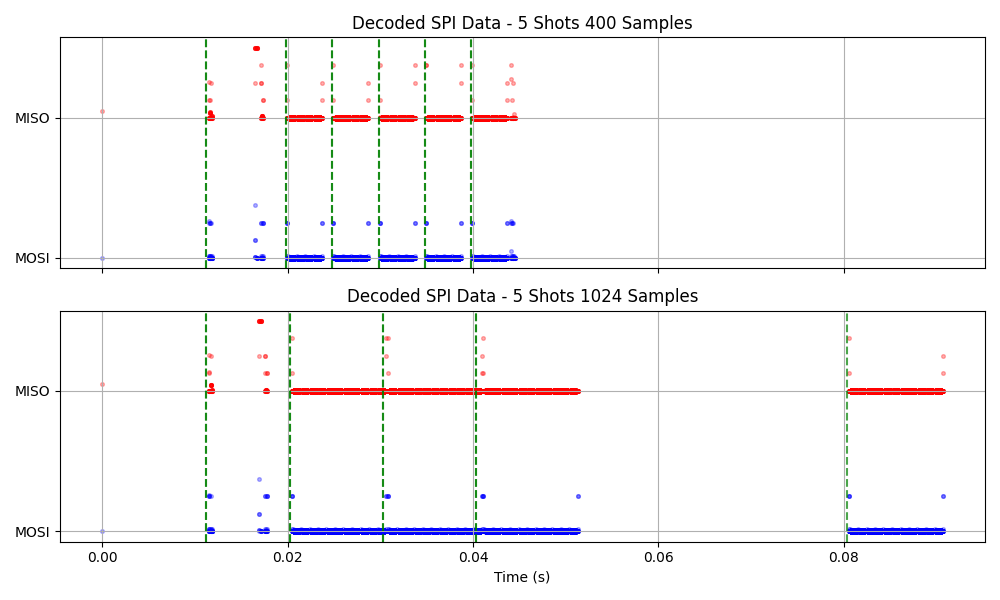

In [33]:
from tqdm import tqdm

# FILES = {
#     "Successful 1": "tp_1.bin",
#     "Successful 2": "tp_3.bin",
#     "Successful 3": "tp_5.bin",
#     "4 Fail 1": "tp_2.bin",
#     "4 Fail 2": "tp_4.bin"
# }
# FILES = {
#     "Successful 1": "tp_10.bin",
#     "Successful 2": "tp_11.bin",
# }
# FILES = {
#     "FIFO 400 bytes": "tp_1.bin",
#     "FIFO 1024 bytes": "tp_6.bin",
#     "FIFO 2048 bytes": "tp_10.bin",
# }
# FILES = {
#     "Successful 1": "tp_12.bin",
#     "Successful 2": "tp_15.bin",
#     "4 Fail 1": "tp_13.bin",
#     "4 Fail 2": "tp_14.bin",
# }
FILES = {
    "5 Shots 400 Samples": "tp_16.bin",
    "5 Shots 1024 Samples": "tp_18.bin",
}

SIGNALS = {'nCS': 3, 'CLK': 0, 'MOSI': 1, 'MISO': 2, 'nINT': 4}

F_ACQ = 100e6
DATA_DIR = "data/semaphore_fix/data_20251216"

decoded_traces = {
    name: parse_decode_signals(
        np.fromfile(f"{DATA_DIR}/{filename}", dtype=np.uint8),
        F_ACQ,
        SIGNALS
    ) for name, filename in tqdm(FILES.items(), desc="Decoding SPI traces")
}
plot_decoded_spi(decoded_traces)

In [31]:
start_time = 18e-3
end_time = 23e-3
for name, trace in decoded_traces.items():
    (times, mosi, miso), _ = trace
    count = np.sum((times >= start_time) & (times <= end_time))
    print(f"{name}:\tMISO bytes between {start_time*1e3:.1f}ms and {end_time*1e3:.1f}ms: {count}")

Successful 1:	MISO bytes between 18.0ms and 23.0ms: 4018
Successful 2:	MISO bytes between 18.0ms and 23.0ms: 4018
4 Fail 1:	MISO bytes between 18.0ms and 23.0ms: 4018
4 Fail 2:	MISO bytes between 18.0ms and 23.0ms: 4018
